# Does Increasing the Advertising Budget Have a Statistically Significant Effect on Sales?

### Using regression and the inferential tools from descriptive and inferential statistics, I test this hypothesis and let the evidence decide.

**Author:** Nitesh Talukdar  
**Role:** Marketing Data Scientist  
**Dataset:** [Google Ads, Data Analytics Course Sales (Kaggle)](https://www.kaggle.com/datasets/nayakganesh007/google-ads-sales-dataset)


## About this project
I am working as a marketing data scientist for a company that sells a Data
Analytics course using Google Ads. The marketing team spends money on ads every
quarter and they want to know one thing:

If we spend more money on ads, do we actually get more sales?

So my goal is to look at the data and find out if there is a real connection
between how much we spend (Cost) and how much we sell (Sale_Amount).

## What I want to find out
- Is there a relationship between ad budget and sales?
- Is that relationship strong enough to be real, or could it just be random?

## My hypothesis
- H0 (null): The ad budget has no effect on sales.
- H1 (alternative): The ad budget does have an effect on sales.

## What success looks like
For me, success is not getting a high score on the model. Success is getting an
honest answer to the question. Even if the answer is "no, spending more does not
help", that is still useful for the business to know.

#### Importing the neccessary libraries

In [1]:
# Data handling and math
import pandas as pd
import numpy as np

# Charts
import matplotlib.pyplot as plt
import seaborn as sns

# Stats and regression
import statsmodels.api as sm
from scipy import stats

# Model building and checking
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Make charts show up inside the notebook
%matplotlib inline

#### Loading and inspecting the data



In [2]:
df = pd.read_csv("GoogleAds_DataAnalytics_Sales_Uncleaned.csv")

In [3]:
df.head(10)

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,$231.88,14.0,7.0,0.058,$1892,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,$216.84,10.0,8.0,0.046,$1679,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,$203.66,26.0,9.0,NaN,$1624,2024/11/16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,$237.66,17.0,6.0,NaN,$1225,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,$195.9,30.0,8.0,NaN,$1091,2024-11-22,hyderabad,desktop,online data analytic
5,A1005,DataAnalyticsCourse,195.0,3776.0,$243.57,10.0,8.0,NaN,$1315,16-11-2024,hyderabad,MOBILE,data anaytics training
6,A1006,Data Analytics Corse,116.0,4480.0,$237.79,17.0,5.0,0.043,$1640,06-11-2024,hyderabad,TABLET,data analytics course
7,A1007,Data Analytics Corse,184.0,5060.0,$229.61,23.0,3.0,0.016,$1509,2024/11/24,Hyderbad,TABLET,analytics for data
8,A1008,Data Analytics Corse,113.0,5434.0,NaN,27.0,4.0,0.058,$1362,2024/11/24,Hyderbad,Tablet,data anaytics training
9,A1009,Data Analytcis Course,166.0,3355.0,$186.78,24.0,9.0,0.054,$1029,2024/11/12,Hyderbad,Mobile,online data analytic


#### First glance at the dataset

1. It looks like The Cost and Sale_Amount columns have a dollar sign in front of the numbers, like $231.88. That means Python is reading them as text, not numbers. We cannot do math on text, so we will need to clean that later.
2. The Ad_Date column has dates written in different formats, like 2024-11-16 in one row and 20-11-2024 in another. That is messy and we will fix it.
3. I noticed that Campaign_Name, Location, and Device have spelling differences and different capital letters, like Desktop, desktop, and DESKTOP. To the computer those look like three different things even though they mean the same.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ad_ID            2600 non-null   object 
 1   Campaign_Name    2600 non-null   object 
 2   Clicks           2488 non-null   float64
 3   Impressions      2546 non-null   float64
 4   Cost             2503 non-null   object 
 5   Leads            2552 non-null   float64
 6   Conversions      2526 non-null   float64
 7   Conversion Rate  1974 non-null   float64
 8   Sale_Amount      2461 non-null   object 
 9   Ad_Date          2600 non-null   object 
 10  Location         2600 non-null   object 
 11  Device           2600 non-null   object 
 12  Keyword          2600 non-null   object 
dtypes: float64(5), object(8)
memory usage: 264.2+ KB


###### What the info tells me

- The dataset has 2600 rows and 13 columns.
- As I expected, Cost and Sale_Amount show up as "object", which means Python is
  reading them as text because of the dollar sign. I will need to fix this.
- A few columns have missing values, since their non empty counts are lower than
  the total number of rows. The ones with missing data are:
  Clicks, Impressions, Cost, Leads, Conversions, Conversion Rate, and Sale_Amount.
- I will deal with these missing values during the cleaning step.

In [5]:
df.isnull().sum()

Ad_ID                0
Campaign_Name        0
Clicks             112
Impressions         54
Cost                97
Leads               48
Conversions         74
Conversion Rate    626
Sale_Amount        139
Ad_Date              0
Location             0
Device               0
Keyword              0
dtype: int64

##### Missing values, exact counts

Using df.isnull().sum(), here is how many values are missing in each column:

- Clicks: 112
- Impressions: 54
- Cost: 94
- Leads: 48
- Conversions: 74
- Conversion Rate: 626
- Sale_Amount: 139

All other columns are complete. Conversion Rate has the most gaps, so I will pay
extra attention to it during cleaning.

#### Cleaning the data
##### Before I can analyze anything, I need to clean the dataset. From my first look, I found a few problems to fix:

1. Cost and Sale_Amount are stored as text because of the dollar sign, so I will
   turn them into real numbers.
2. The Ad_Date column has dates in different formats, so I will make them
   consistent.
3. Campaign_Name, Location, and Device have spelling and capital letter
   differences, so I will tidy them up.
4. Several columns have missing values, so I will decide how to handle them.

I will fix these one at a time.

In [6]:
# removing the $ sign from the Cost column and turn it into float
df["Cost"] = df["Cost"].str.replace("$", "", regex=False)
df["Cost"] = df["Cost"].astype(float)

In [7]:
# removing the $ sign from the Sale_Amount column and turn it into float
df["Sale_Amount"] = df["Sale_Amount"].str.replace("$", "", regex=False)
df["Sale_Amount"] = df["Sale_Amount"].astype(float)

In [10]:
df[["Cost", "Sale_Amount"]].dtypes

Cost           float64
Sale_Amount    float64
dtype: object

##### fixing the messy dates

The Ad_Date column is messy. The dates were written in different formats, like
2024-11-16, 20-11-2024, and 2024/11/16. Because of this, Python was reading them
as plain text instead of real dates.

I used pd.to_datetime with format="mixed" so that pandas looks at each date one by
one and figures out its format, instead of expecting them all to look the same.
After this, the Ad_Date column became a proper date type, so I can sort by date or
pull out the month later if I need to.

Note: a few dates like 06-11-2024 are confusing, because they could mean
the 6th of November or the 11th of June. There is no perfect way to know for sure
which one was meant. I told pandas to read the month first in these cases. This is a
real limitation in the data, and I am noting it here.

In [12]:
df["Ad_Date"] = pd.to_datetime(df["Ad_Date"], format="mixed", dayfirst=False)

##### Cleaning the text columns

The Device, Location, and Campaign_Name columns have messy text. The same thing is
written in different ways, using different capital letters and spellings. To the
computer these look like separate values even though they mean the same thing. I
will clean them so each real category is counted as one.

In [13]:
df["Device"].value_counts()

Device
MOBILE     311
desktop    305
Desktop    305
tablet     305
Mobile     291
TABLET     279
DESKTOP    278
mobile     276
Tablet     250
Name: count, dtype: int64

In [14]:
df["Device"] = df["Device"].str.lower()
df["Device"].value_counts()

Device
desktop    888
mobile     878
tablet     834
Name: count, dtype: int64

For the Device column, the only problem was the capital letters. There were no
spelling mistakes, so making everything lowercase was enough. After this fix, the
many fake groups like MOBILE, Mobile, and mobile all became one clean value, and
Device now has just three real categories: mobile, desktop, and tablet.

The Location column is a bit trickier. It does not just have capital letter
problems, it also has real spelling mistakes like "hyderbad" and "hydrebad". So
lowercasing alone will not fully fix it. I will handle Location next with one
extra step.

In [15]:
df["Location"].value_counts()

Location
HYDERABAD    661
Hyderbad     656
hyderabad    650
hydrebad     633
Name: count, dtype: int64

In [17]:
df["Location"] = "hyderabad"
df["Location"].value_counts()

Location
hyderabad    2600
Name: count, dtype: int64

In [18]:
df["Campaign_Name"].value_counts()

Campaign_Name
Data Analytcis Course    680
Data Analytics Corse     647
DataAnalyticsCourse      637
Data Anlytics Corse      636
Name: count, dtype: int64

In [20]:
df["Campaign_Name"] = "Data Analytics Course"
df["Campaign_Name"].value_counts()

Campaign_Name
Data Analytics Course    2600
Name: count, dtype: int64

#### A note on the scope of this data

After cleaning the text columns, I noticed something important. Both Location and
Campaign_Name turned out to have only one real value each. Every row is the same
city, Hyderabad, and every row is the same campaign, the Data Analytics Course.

This tells me something about the dataset as a whole: it covers a single campaign
running in a single city. So my analysis is really about one campaign in one place,
not a wide comparison across many campaigns or cities.

This also means these two columns cannot help explain why sales go up or down,
because they never change. A column that has the same value in every row carries no
useful information for a model. So I will likely drop both Location and
Campaign_Name later, during feature selection.

### Handling missing values

In [21]:
df.isnull().sum()

Ad_ID                0
Campaign_Name        0
Clicks             112
Impressions         54
Cost                97
Leads               48
Conversions         74
Conversion Rate    626
Sale_Amount        139
Ad_Date              0
Location             0
Device               0
Keyword              0
dtype: int64

Several columns have missing values: Clicks, Impressions, Cost, Leads, Conversions,
Conversion Rate, and Sale_Amount. How I handle these is a real decision.

When a value is missing, there are three main choices:
1. Drop the rows that have missing values. Simple, but I lose data.
2. Fill the gap with a typical value, like the mean or the median.
3. Leave it, but only if I will not use that column.

When filling missing numbers, I will use the median instead of the mean. The reason
is that the mean gets pulled around by very high or very low data values, while the
median is the middle value and stays steady. So the median is the safer choice for messy data.

But two columns are special and I will treat them differently:

- Sale_Amount is my target, the thing I am trying to study. I should never invent
  values for my target, because that would be like making up the answers to my own
  test. I have 2600 rows, which is a large sample. Dropping a few hundred rows still
  leaves me with plenty of data to analyze, so I can afford to drop rows with a
  missing target or budget instead of inventing values. So for rows where
  Sale_Amount is missing, I will drop those rows instead of filling them.

- Cost is my main predictor, the ad budget. It is the most important input for my
  question. If I fill it with a median, I would blur the exact relationship I am
  trying to measure. So I will also drop rows where Cost is missing, rather than
  invent budgets.

So my plan is:
- Drop rows where Sale_Amount or Cost is missing, because these two are the heart of
  my analysis and I will not fake them.
- For the other number columns, fill the gaps with the median, since they are
  supporting features.

 Having a large sample also helps me later. The central limit theorem says that with
a big enough sample, the results behave in a predictable, bell shaped way, which
makes my hypothesis test and regression later more trustworthy. So my large sample
helps in two ways: it lets me drop a few rows safely, and it makes my final test
more reliable.

In [24]:
df = df.dropna(subset=["Sale_Amount"])
df = df.dropna(subset=["Cost"])

In [25]:
df.shape

(2366, 13)

In [26]:
df["Clicks"] = df["Clicks"].fillna(df["Clicks"].median())

In [27]:
# fill the rest of the supporting number columns with their median using loop
for col in ["Impressions", "Leads", "Conversions", "Conversion Rate"]:
    df[col] = df[col].fillna(df[col].median())

In [28]:
df.isnull().sum()

Ad_ID              0
Campaign_Name      0
Clicks             0
Impressions        0
Cost               0
Leads              0
Conversions        0
Conversion Rate    0
Sale_Amount        0
Ad_Date            0
Location           0
Device             0
Keyword            0
dtype: int64

In [29]:
df.describe()

,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date
count,2366.000000,2366.000000,2366.000000,2366.000000,2366.000000,2366.000000,2366.000000,2366
mean,138.716399,4523.935334,214.933833,19.994928,6.536771,0.048349,1499.692730,2024-10-30 10:22:37.227387904
min,80.000000,3000.000000,180.010000,10.000000,3.000000,0.015000,1000.000000,2024-01-11 00:00:00
25%,110.000000,3781.750000,197.285000,15.000000,5.000000,0.038000,1248.000000,2024-11-07 00:00:00
50%,139.000000,4524.000000,215.305000,20.000000,7.000000,0.046000,1506.000000,2024-11-16 00:00:00
75%,167.000000,5259.250000,232.695000,25.000000,8.000000,0.054000,1743.000000,2024-11-23 00:00:00
max,199.000000,5999.000000,249.890000,30.000000,10.000000,0.123000,2000.000000,2024-12-11 00:00:00
std,34.015012,857.377468,20.306830,5.995627,2.242988,0.017529,287.820796,NaN


A couple of things stand out from the summary:

- Cost (the ad budget) ranges from about 180 to 250, with an average of around 215.
  The mean (214.93) and the median (215.31) are almost the same, which tells me the
  budget values are fairly balanced and not skewed to one side.

- Sale_Amount (the sales) ranges from 1000 to 2000, with an average of around 1500.
  The mean (1499.69) and the median (1506) are very close too, so the sales values
  also look fairly balanced.

After cleaning, the dataset has 2366 rows left out of the original 2600. I dropped
234 rows that were missing a sales value or a budget value. That is a small portion,
so I still have a large sample to work with.

### Looking at the relationship between budget and sales

Before building any model, I want to see the relationship with a scatter plot which
puts the budget on one axis and the sales on the other, so I can see if higher
spending tends to come with higher sales, or if there is no clear pattern at all.

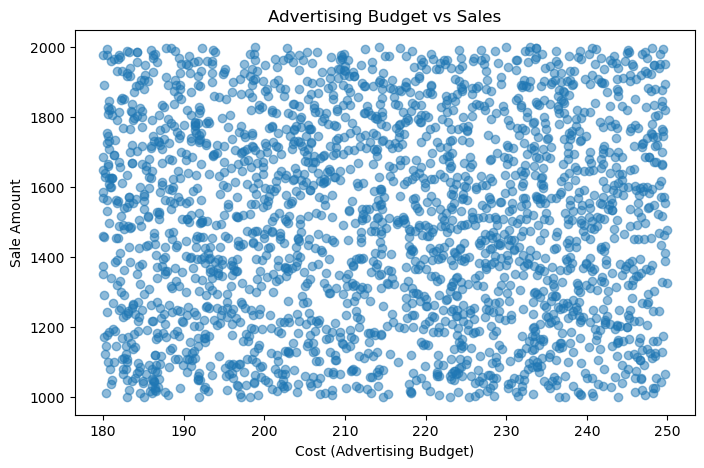

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Cost"], df["Sale_Amount"], alpha=0.5)
plt.title("Advertising Budget vs Sales")
plt.xlabel("Cost (Advertising Budget)")
plt.ylabel("Sale Amount")
plt.show()

### What the scatter plot shows

The dots fill the whole chart evenly, with no clear shape. Whether the budget is low
(around 180) or high (around 250), the sales still spread all the way from 1000 to
2000. There is no upward slope and no downward slope.

If higher budgets really led to higher sales, I would expect the dots to lean
upward to the right, forming a tilted oval shape. Instead they form a cloud of dots. This is my first piece of evidence that the ad budget may not have a real
effect on sales. I will now measure this properly with a correlation number to
confirm what my eyes are telling me.

## Measuring the relationship with correlation (r)

The scatter plot suggested there is no real link between budget and sales, but a
picture can be read differently by different people. So I will measure it properly
using the correlation coefficient, called r.

The value of r always sits between -1 and +1:
- Close to +1 means a strong positive link (as one goes up, the other goes up).
- Close to -1 means a strong negative link (as one goes up, the other goes down).
- Close to 0 means there is almost no linear link at all.

In [31]:
df["Cost"].corr(df["Sale_Amount"])

np.float64(0.010844580865651769)

The correlation between budget and sales is about 0.011, which is extremely
close to zero. On the scale from -1 to +1, this means there is almost no linear
relationship between the two. This agrees with what the scatter plot showed: 
**more
spending does not line up with more sales in this data**.

### The full correlation picture (heatmap)

I just measured the correlation between budget and sales. Now I want to see the
correlation between all the number columns at once, to check if any other feature
has a stronger link with sales than the budget does. A heatmap shows all these
correlations in one colored grid, which is easy to scan quickly.

In [32]:
df.corr(numeric_only=True)

,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount
Clicks,1.000000,0.003279,0.038073,0.054786,-0.000265,-0.428606,0.040551
Impressions,0.003279,1.000000,0.003297,-0.040349,-0.015053,0.012251,-0.004629
Cost,0.038073,0.003297,1.000000,-0.015784,0.003602,-0.011517,0.010845
Leads,0.054786,-0.040349,-0.015784,1.000000,0.022117,-0.020039,0.010610
Conversions,-0.000265,-0.015053,0.003602,0.022117,1.000000,0.558193,0.003301
Conversion Rate,-0.428606,0.012251,-0.011517,-0.020039,0.558193,1.000000,-0.049593
Sale_Amount,0.040551,-0.004629,0.010845,0.010610,0.003301,-0.049593,1.000000


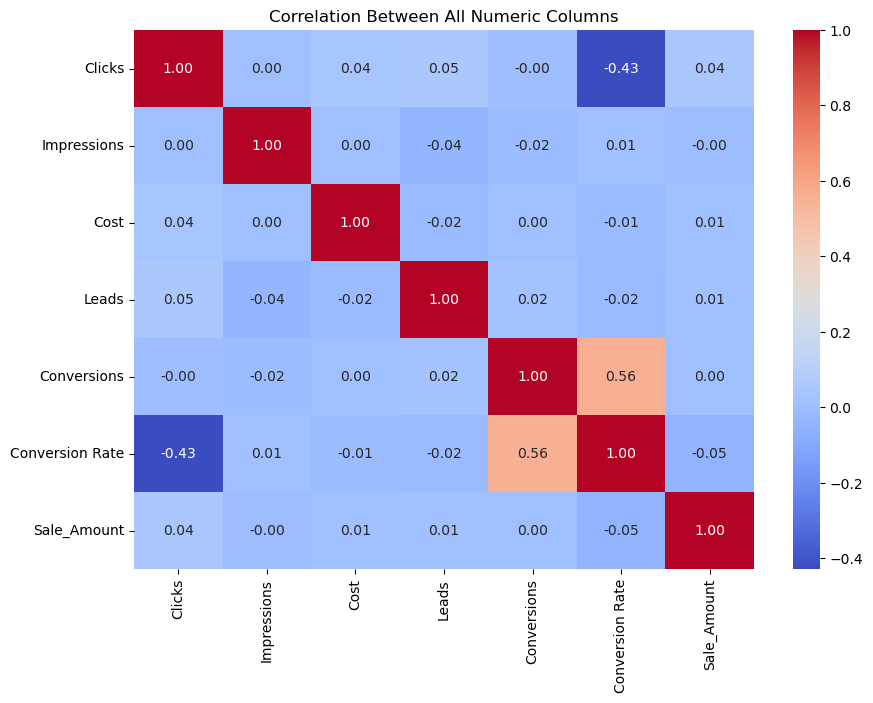

In [33]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between All Numeric Columns")
plt.show()

#### What the heatmap shows

The row I care about is Sale_Amount. Looking across it, the correlation between
sales and every other feature is very close to zero:
- Cost: 1%
- Clicks: 4%
- Impressions: 0%
- Leads: 1%
- Conversions: 0%
- Conversion Rate: 5% (negatively)

This is an important finding. It is not just that budget has no link with sales,
none of the features of this dataset do. So it is not that I picked the wrong column. Instead, none of the ad metrics in this dataset seem to explain the sales.

This actually makes my conclusion more interesting. It suggests that sales here are
driven by something that is not captured in this data at all, rather than by any of
the advertising numbers I have. I will confirm the budget result with a formal
significance test next.

### The formal significance test (regression)

So far I have seen a flat scatter plot and a near zero correlation. Both suggest no
real link between budget and sales. But to actually test my hypothesis, I need a
formal statistical test that gives a p-value.

My hypotheses, from the start of the project:
- H0 (null): the ad budget has no real effect on sales (the true slope is 0).
- H1 (alternative): the ad budget does have a real effect on sales (the slope is
  not 0).

**I will fit a simple linear regression using statsmodels, because it gives a full
report with the slope, the p-value, and the R-squared. The p-value is what decides
between H0 and H1.**

In [34]:
X = df["Cost"]
X = sm.add_constant(X) # adding the intercept
y = df["Sale_Amount"]

In [35]:
model = sm.OLS(y, X).fit()

Behind this one line above, statsmodels drew the best possible straight line through the scatter cloud and measured everything about it: the slope, the intercept, how much of the sales it can explain, and crucially, whether the slope is statistically real or could just be random noise. All of that is now stored inside model.

In [36]:
# the reportig line
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Sale_Amount   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2781
Date:                Sun, 31 May 2026   Prob (F-statistic):              0.598
Time:                        05:58:31   Log-Likelihood:                -16754.
No. Observations:                2366   AIC:                         3.351e+04
Df Residuals:                    2364   BIC:                         3.352e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1466.6560     62.931     23.306      0.0

### Reading the regression report

Three numbers from the report give me my answer:

- **Slope (Cost coef): 0.1537.** On the surface, this says each extra dollar of
  budget is linked to about 15 currency value more in sales. But it should not be trusted until I check if it is statistically real.
- **P-value (P>|t| for Cost): 0.598.** This is the key number. The cutoff is 0.05.
  Since 0.598 is far above 0.05, so we fail to reject H0. There is no statistical
  evidence that the budget has a real effect on sales. The slope of 0.15 is
  **basically just random noise**.
- **R-squared: 0.000.** The budget explains almost none of the changes in sales.

The confidence interval for the slope runs from -0.418 to 0.725. Because it crosses
zero, the true effect could be negative, positive, or nothing at all. This is one
more sign that we cannot claim any real effect.

**Verdict on my hypothesis:** I fail to reject H0. Based on this data, **increasing
the advertising budget does not have a statistically significant effect on sales**.

### Why I am not building a predictive (scikit-learn) model

At the start, I imported scikit-learn because I planned to also build a predictive
model with a train and test split. That is the normal next step in a data science
project, and I did not want to assume the outcome before testing it.

But now I have clear evidence, so it is worth pausing to think instead of just
continuing out of habit. My regression results showed:
- A p-value of 0.598, far above 0.05, so the budget has no statistically
  significant effect on sales.
- An R-squared of 0.000, meaning the budget explains almost none of the change in
  sales.

A predictive model would only be useful if there were a real relationship to learn
from. Since the relationship is essentially zero, a scikit-learn model would simply
confirm that it cannot predict sales from the budget, which I already know. It would
add code and effort without adding any new insight.

So the honest and efficient choice is to stop here. The statistical test has already
answered my business question completely. Continuing to build models in search of a
result that the data does not support would be the wrong thing to do as an analyst.

# Final Report and Business Conclusion

### The question I set out to answer
As the marketing data scientist, I was asked one thing: if we increase our
advertising budget, do sales actually go up? I tested this properly and let the
evidence decide, rather than relying on opinion.

### What I did
1. Cleaned a messy dataset of 2600 Google Ads records: fixed currency columns,
   standardized dates, tidied inconsistent text, and handled missing values. I
   dropped rows missing the budget or sales (the two columns I refused to manipulate) and
   filled supporting columns with the median. This left me with 2366 clean rows.
2. Explored the data with descriptive statistics and a scatter plot.
3. Measured the link between budget and sales with the correlation coefficient.
4. Ran a formal linear regression to test my hypothesis with a p-value.

### What I found
Every piece of evidence pointed the same way:
- The scatter plot of budget against sales was a flat, shapeless cloud, no upward or downward
  trend.
- The correlation between budget and sales was about 0.011, essentially
  zero.
- The regression gave a p-value of 0.598, far above the 0.05 cutoff, and an
  R-squared of 0.000.

### The verdict
I fail to reject my null hypothesis (H0). Based on this data, increasing the
advertising budget does not have a statistically significant effect on sales.
Spending more does not lead to more sales here.

I also found that no other feature (clicks, impressions, leads, conversions) had a
meaningful link with sales either. So this is not a case of picking the wrong input.
The sales in this dataset seem to be driven by something that was not captured in
the data at all.

### What this means for the business
If I presented this to the marketing team, my honest message would be:
- We do not currently have evidence that raising the ad budget will raise sales. So
  spending more, on its own, is not a safe bet.
- Before increasing spend, we should find out what actually does drive sales. The
  current ad metrics do not explain it.

### What I would recommend next
- Collect richer data that might actually explain sales, such as product price,
  customer type, season, competitor activity, or ad creative quality.
- Run a controlled test (an A/B test) where we deliberately raise the budget for one
  group and keep it steady for another, then compare. That would give cleaner
  evidence than this data.

### Why this is still a successful project
I set out to answer a real business question with evidence, and I did. A "no effect"
answer is just as valuable to a business as a "yes" answer, because it stops the
company from wasting money on something that does not work.